# Part 2 — Spatial and demographic analysis

This notebook reproduces the Person 2 analysis using the unchanged Part 1 cleaned baseline. The unit of analysis is one recorded arrest. These data describe enforcement and recording activity, not underlying crime incidence.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image, Markdown

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from analyze_spatial_demographic import load_data, calculate_outputs, quality_tables

DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'nypd_arrests_clean.csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'part2'
FIGURE_DIR = PROJECT_ROOT / 'figures' / 'part2'
frame = load_data(DATA_PATH)
results = calculate_outputs(frame)
len(frame)

141870

## 1. Field and quality confirmation

In [2]:
field_quality, validation = quality_tables(frame)
display(field_quality)
display(validation)

,field,non_null,missing_count,missing_pct,unique_values
0,ARREST_BORO,141870,0,0.000,5
1,ARREST_PRECINCT,141870,0,0.000,78
2,AGE_GROUP,141870,0,0.000,5
3,LAW_CAT_CD,141006,864,0.609,6
4,LATITUDE,141870,0,0.000,28237
5,LONGITUDE,141870,0,0.000,28275


,check,value
0,row_count,141870.0000
1,recognised_borough_pct,100.0000
2,recognised_age_pct,100.0000
3,core_fmv_severity_pct,99.0174
4,valid_precinct_pct,100.0000
5,valid_nyc_coordinate_pct,100.0000
6,exact_duplicate_rows_pct,0.0000


The shared dataset retains all six fields required by Part 2. Core F/M/V severity analysis uses 140,476 records; missing and non-core categories remain visible in the audit.

## 2. Spatial concentration

In [3]:
display(results['borough_counts'])
display(results['precinct_counts'].head(15))

,borough,arrest_records
0,Brooklyn,42877
1,Bronx,32682
2,Manhattan,32089
3,Queens,29053
4,Staten Island,5169


,precinct,arrest_records,share_pct
0,75,5341,3.764714
1,14,4382,3.088743
2,40,4061,2.862480
3,46,3951,2.784944
4,44,3882,2.736308
5,103,3837,2.704589
6,73,3524,2.483964
7,52,3409,2.402904
8,47,3084,2.173821
9,110,3001,2.115317


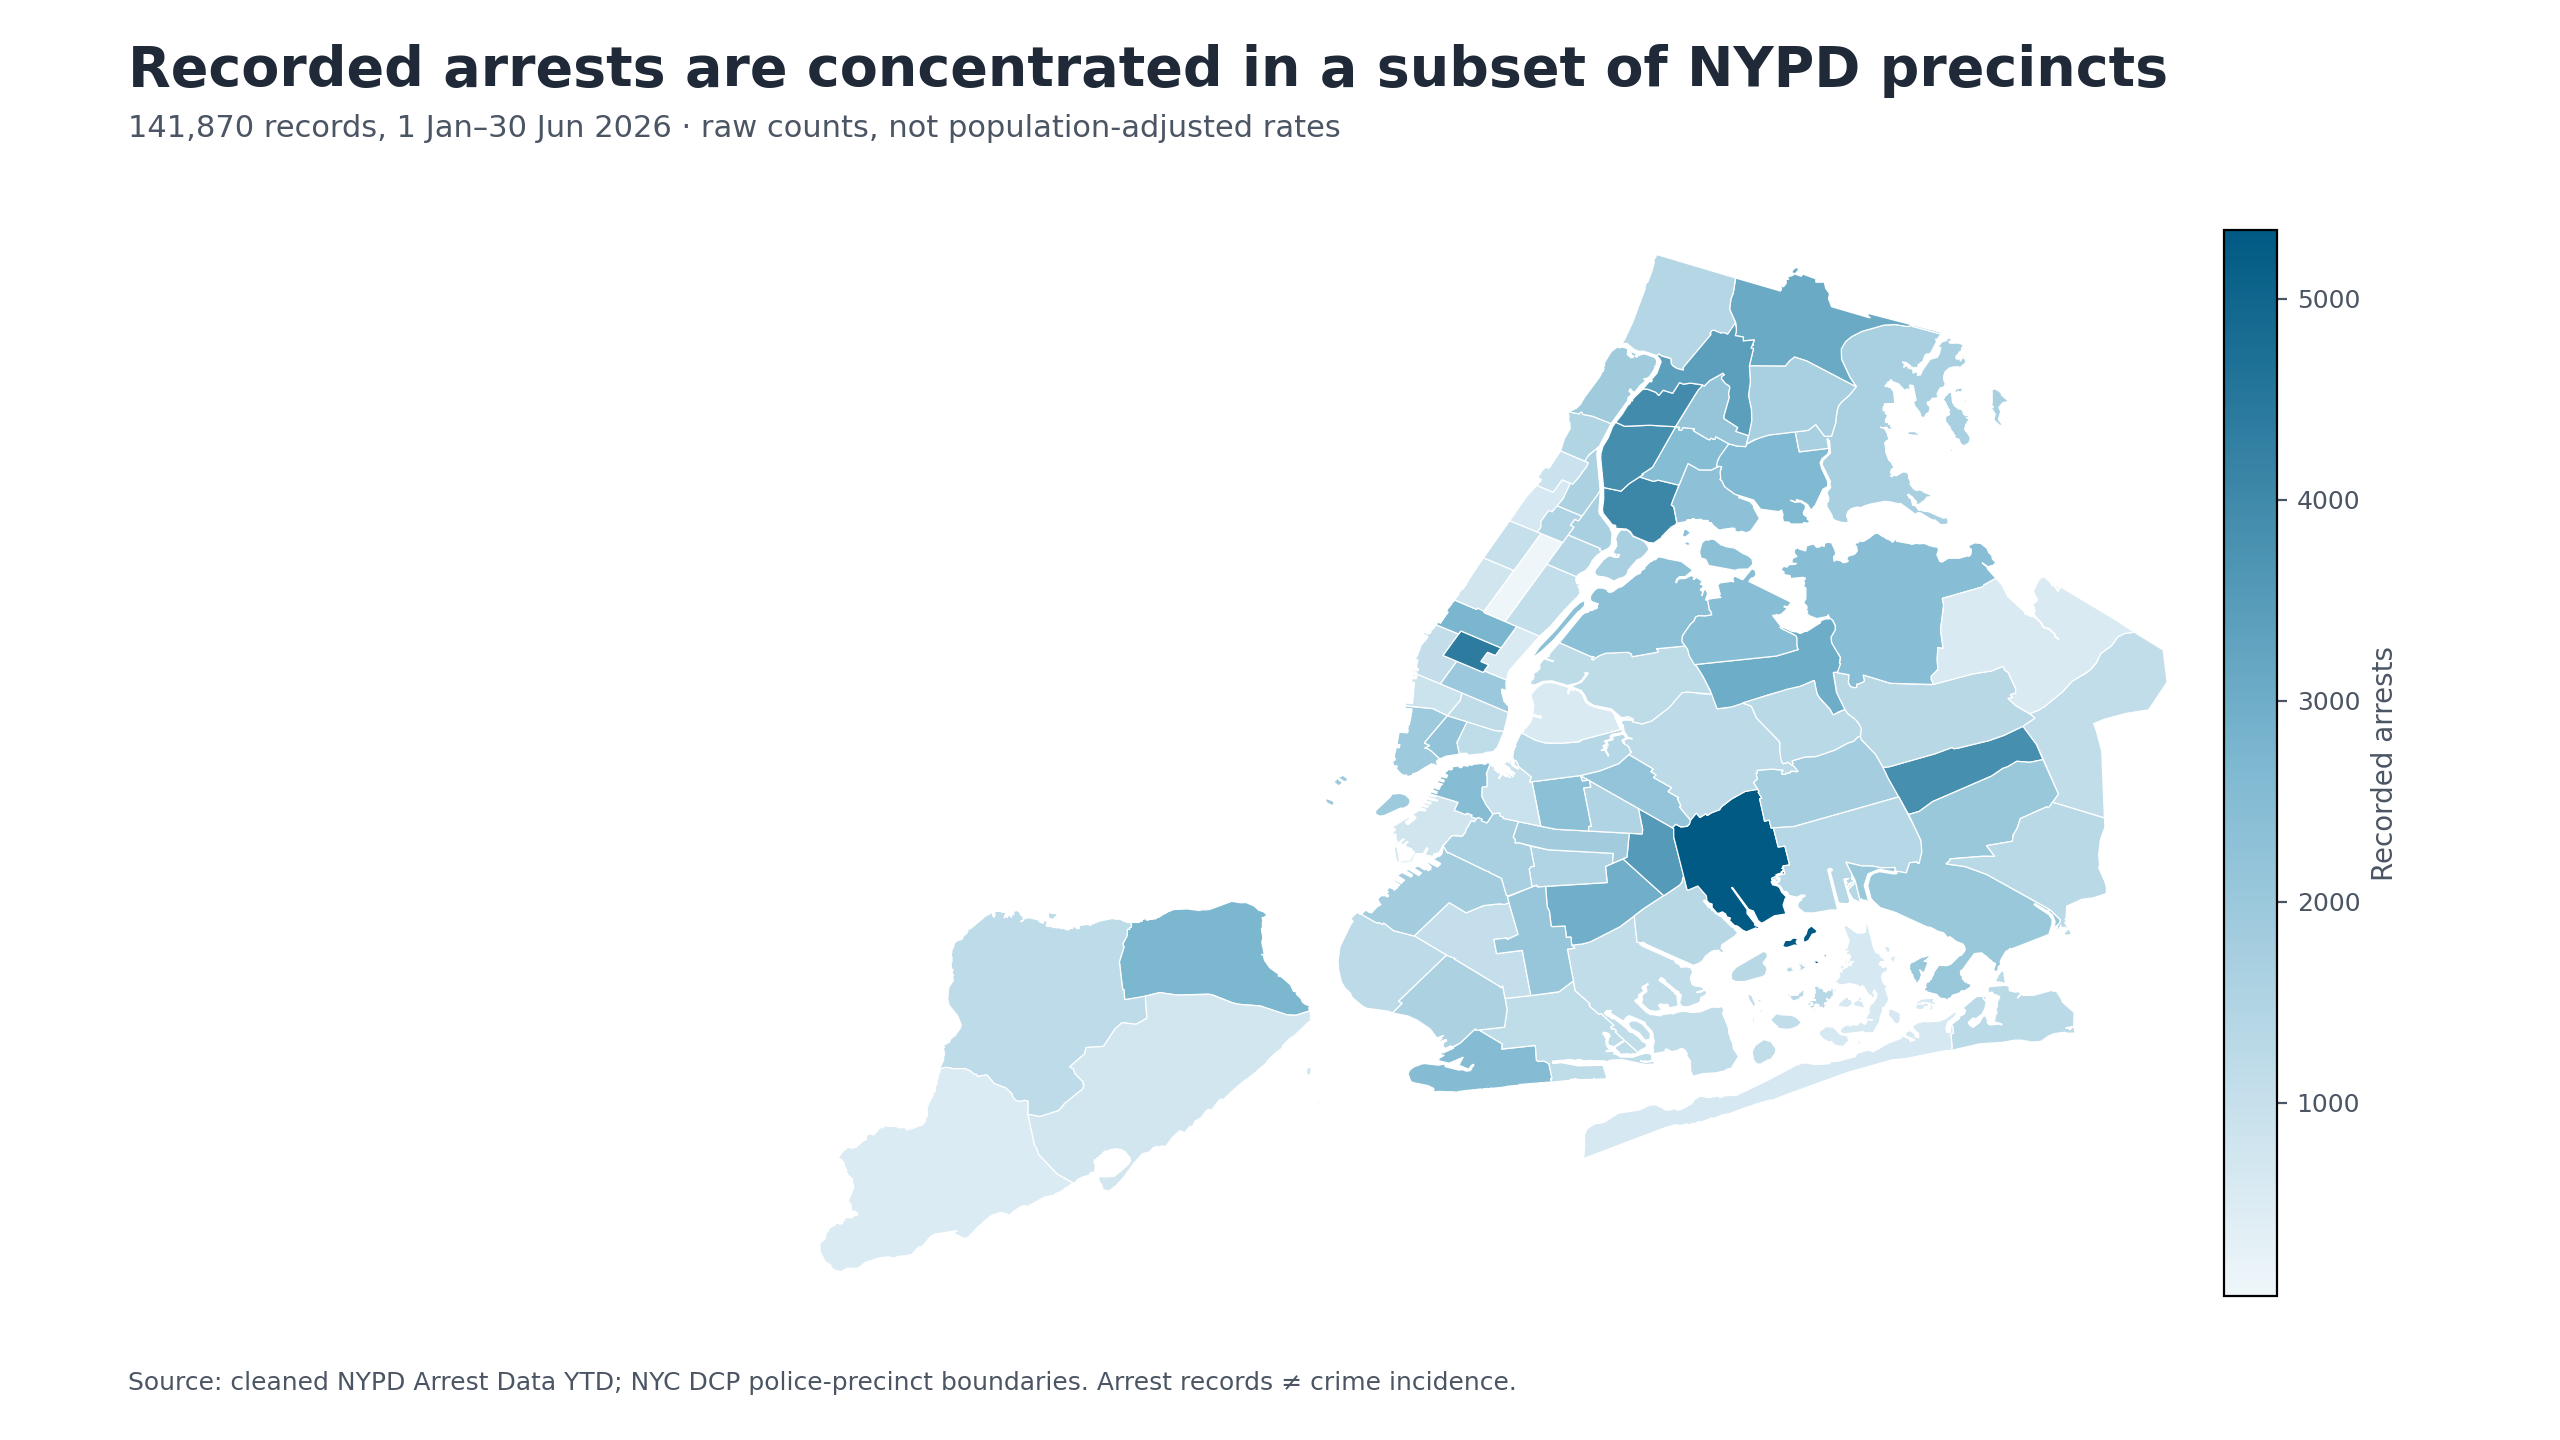

In [4]:
display(Image(filename=str(FIGURE_DIR / '01_precinct_arrest_map.png'), width=1000))

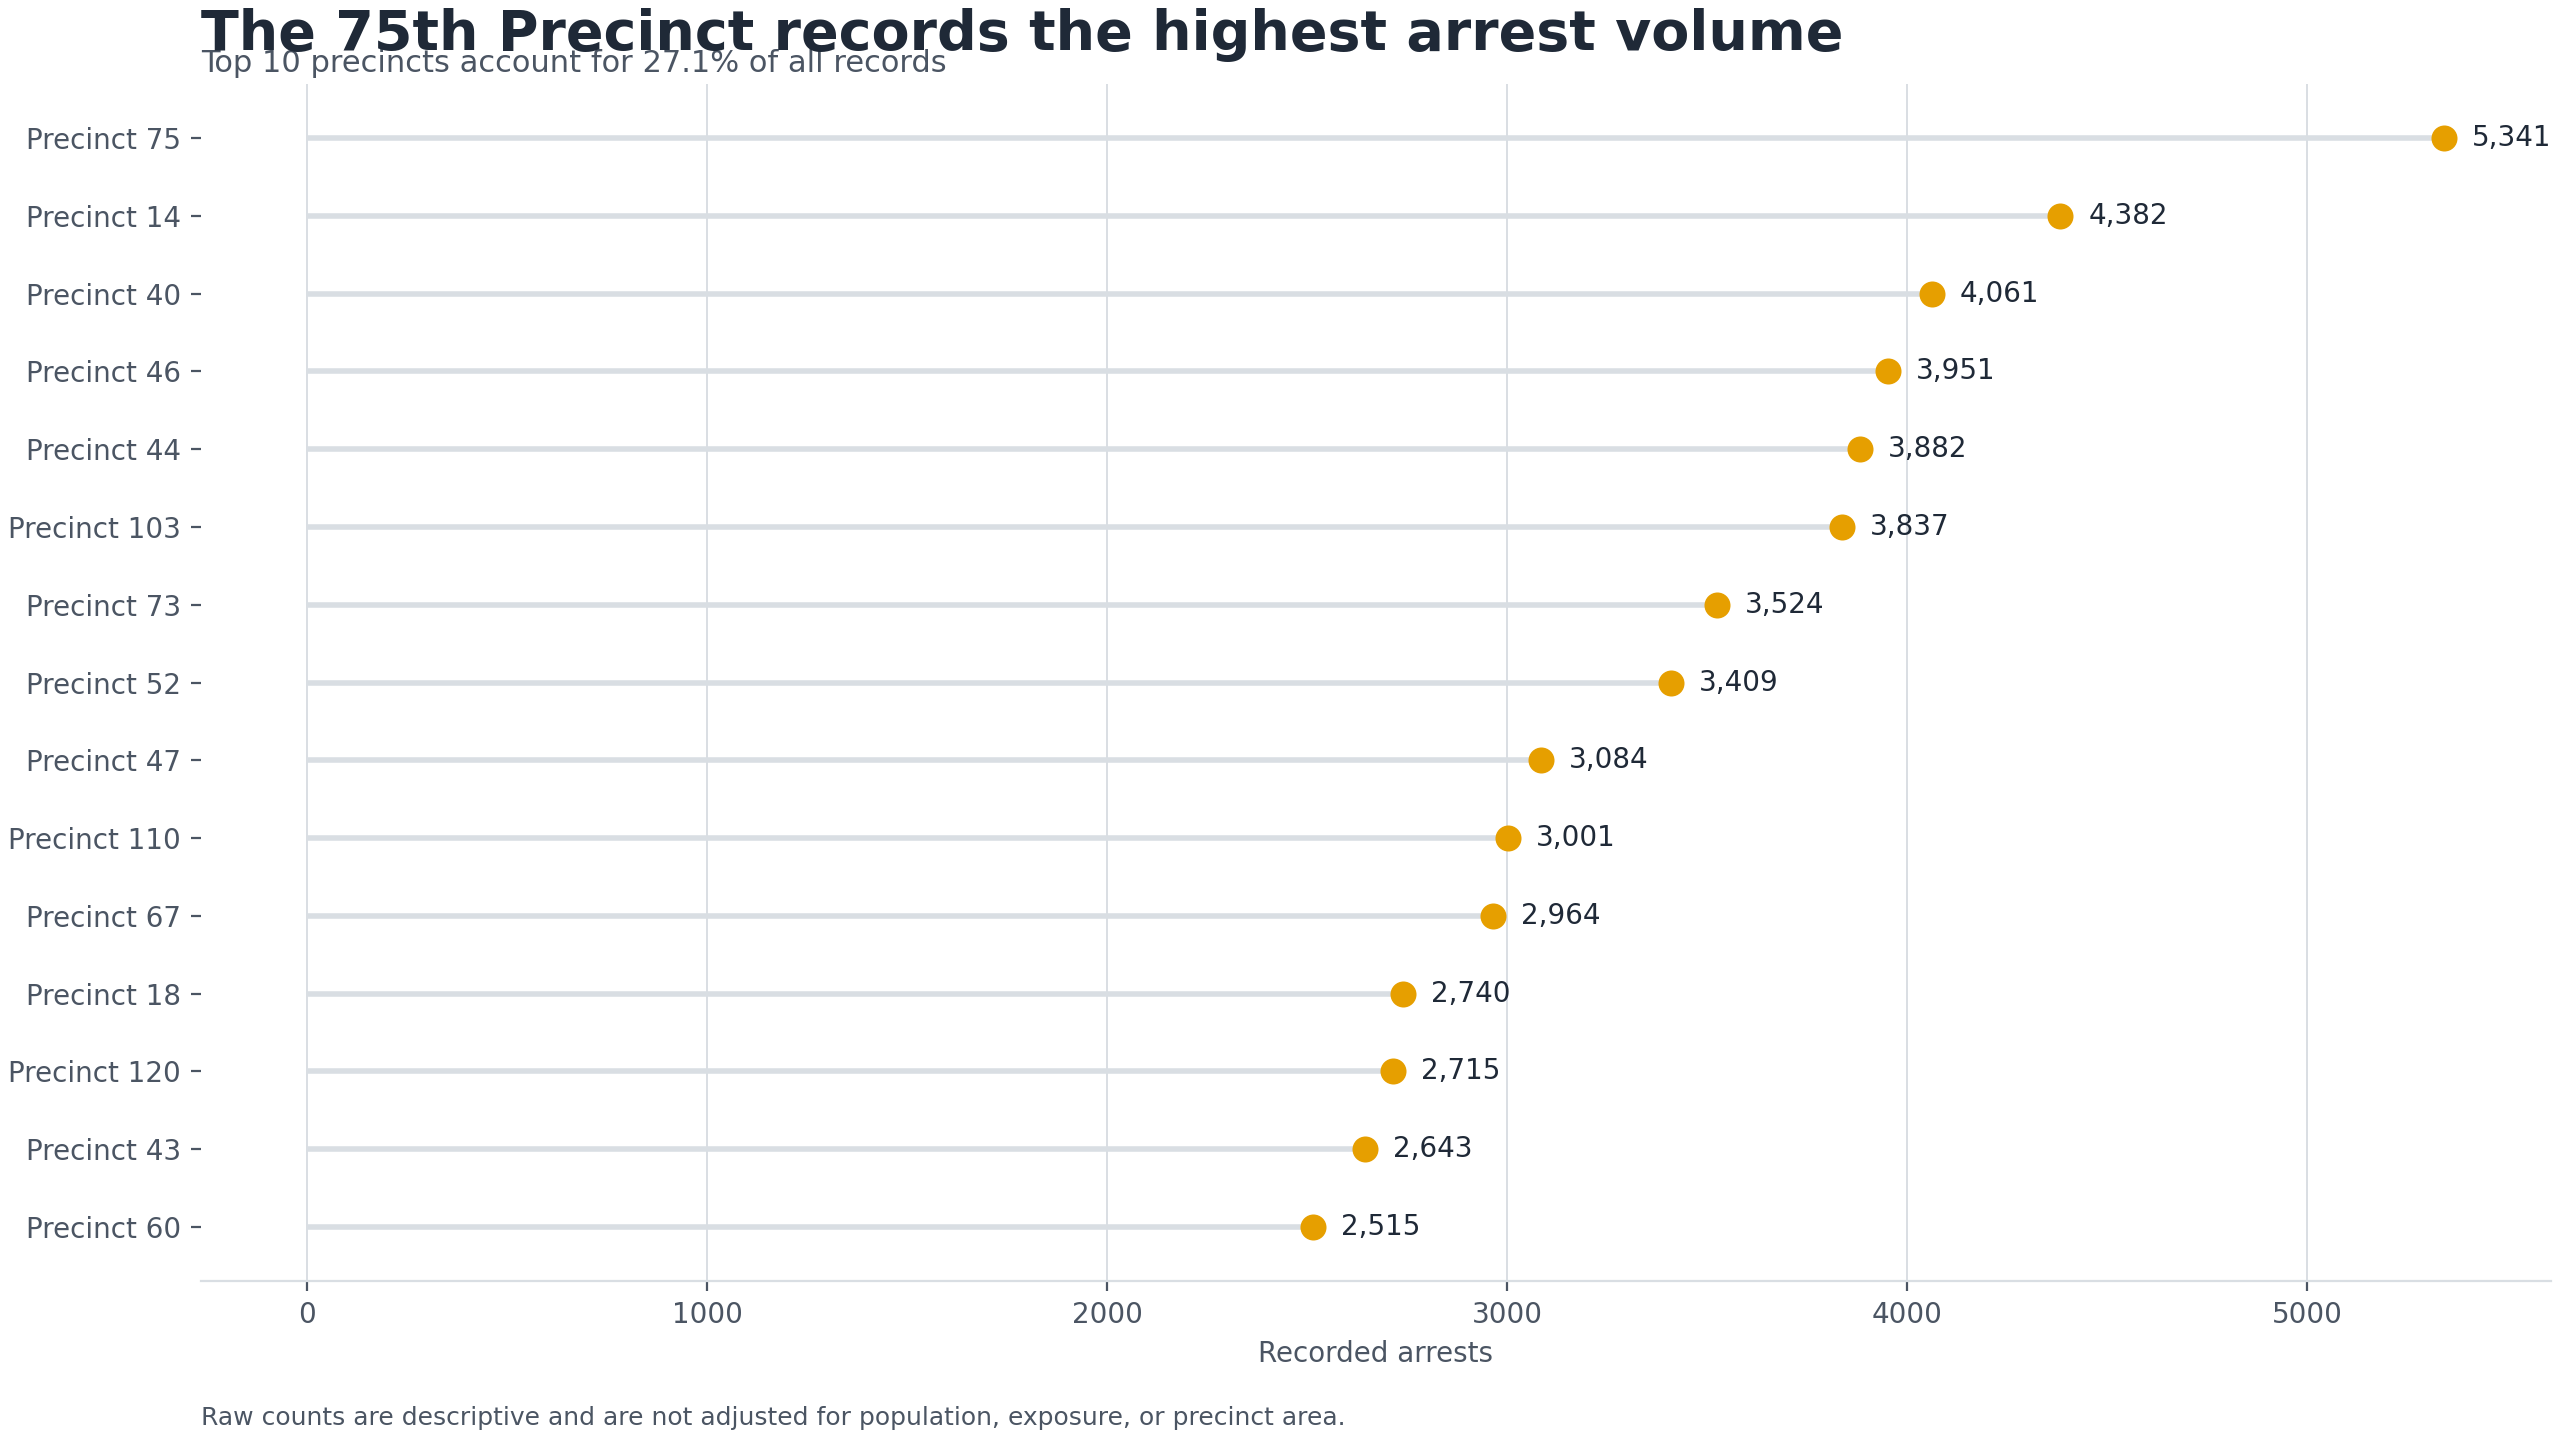

In [5]:
display(Image(filename=str(FIGURE_DIR / '02_top_precincts.png'), width=1000))

Spatial patterns are reported as recorded arrest counts. They are not adjusted for population, exposure, footfall, or precinct area and therefore are not crime rates.

## 3. Age group × severity

In [6]:
display(results['age_severity_counts'])
display(results['age_severity_pct'].round(2))
print("Cramér's V:", round(results['age_cramers_v'], 3))

SEVERITY,Felony,Misdemeanor,Violation
age_group,,,
<18,3531,2054,1
18-24,8644,11928,151
25-44,31259,48252,1134
45-64,11071,18682,582
65+,1146,2013,28


SEVERITY,Felony,Misdemeanor,Violation
age_group,,,
<18,63.21,36.77,0.02
18-24,41.71,57.56,0.73
25-44,38.76,59.83,1.41
45-64,36.50,61.59,1.92
65+,35.96,63.16,0.88


Cramér's V: 0.077


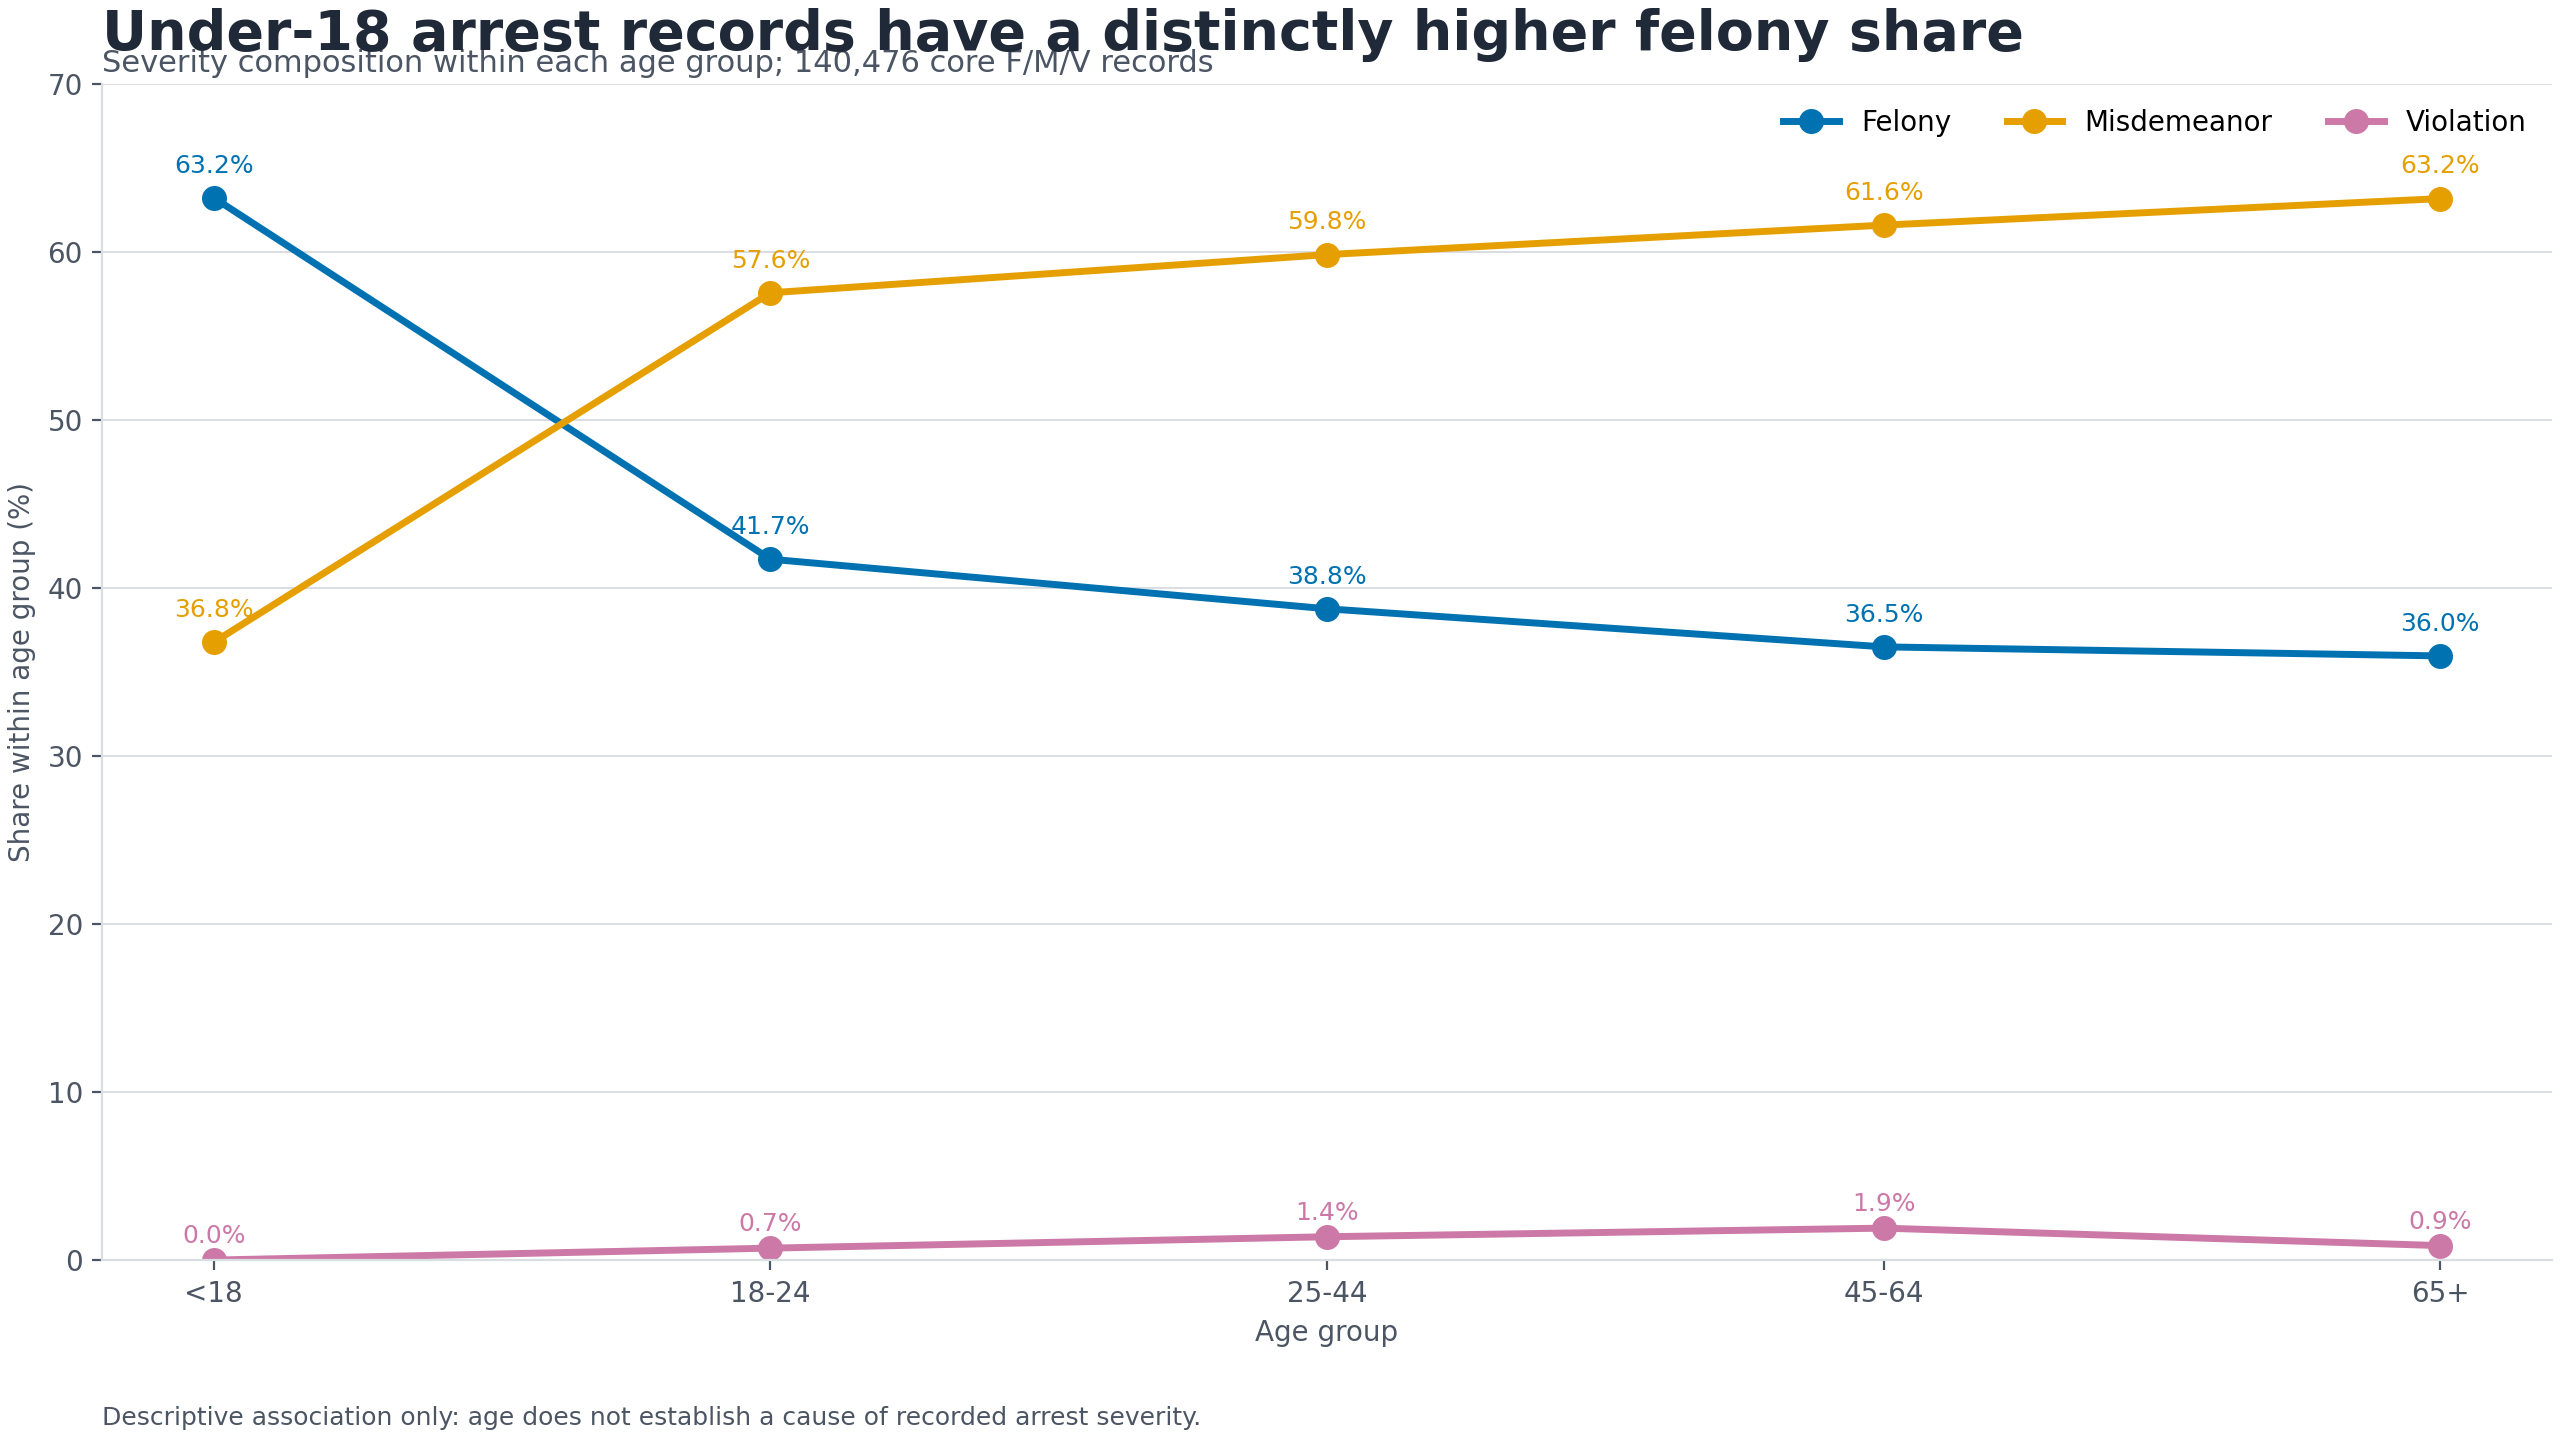

In [7]:
display(Image(filename=str(FIGURE_DIR / '03_age_severity_profile.png'), width=1000))

The under-18 category has the highest felony share. This is a descriptive association within recorded arrests and does not demonstrate that age causes arrest severity.

## 4. Borough × severity

In [8]:
display(results['borough_severity_pct'].round(2))
display(results['borough_severity_delta_pp'].round(2))
print("Cramér's V:", round(results['borough_cramers_v'], 3))

SEVERITY,Felony,Misdemeanor,Violation
borough,,,
Bronx,39.95,59.47,0.59
Brooklyn,40.02,57.22,2.76
Manhattan,38.36,61.28,0.36
Queens,40.05,58.53,1.43
Staten Island,39.46,60.46,0.08


SEVERITY,Felony,Misdemeanor,Violation
borough,,,
Bronx,0.33,0.43,-0.76
Brooklyn,0.41,-1.82,1.41
Manhattan,-1.25,2.25,-0.99
Queens,0.43,-0.51,0.08
Staten Island,-0.16,1.43,-1.27


Cramér's V: 0.064


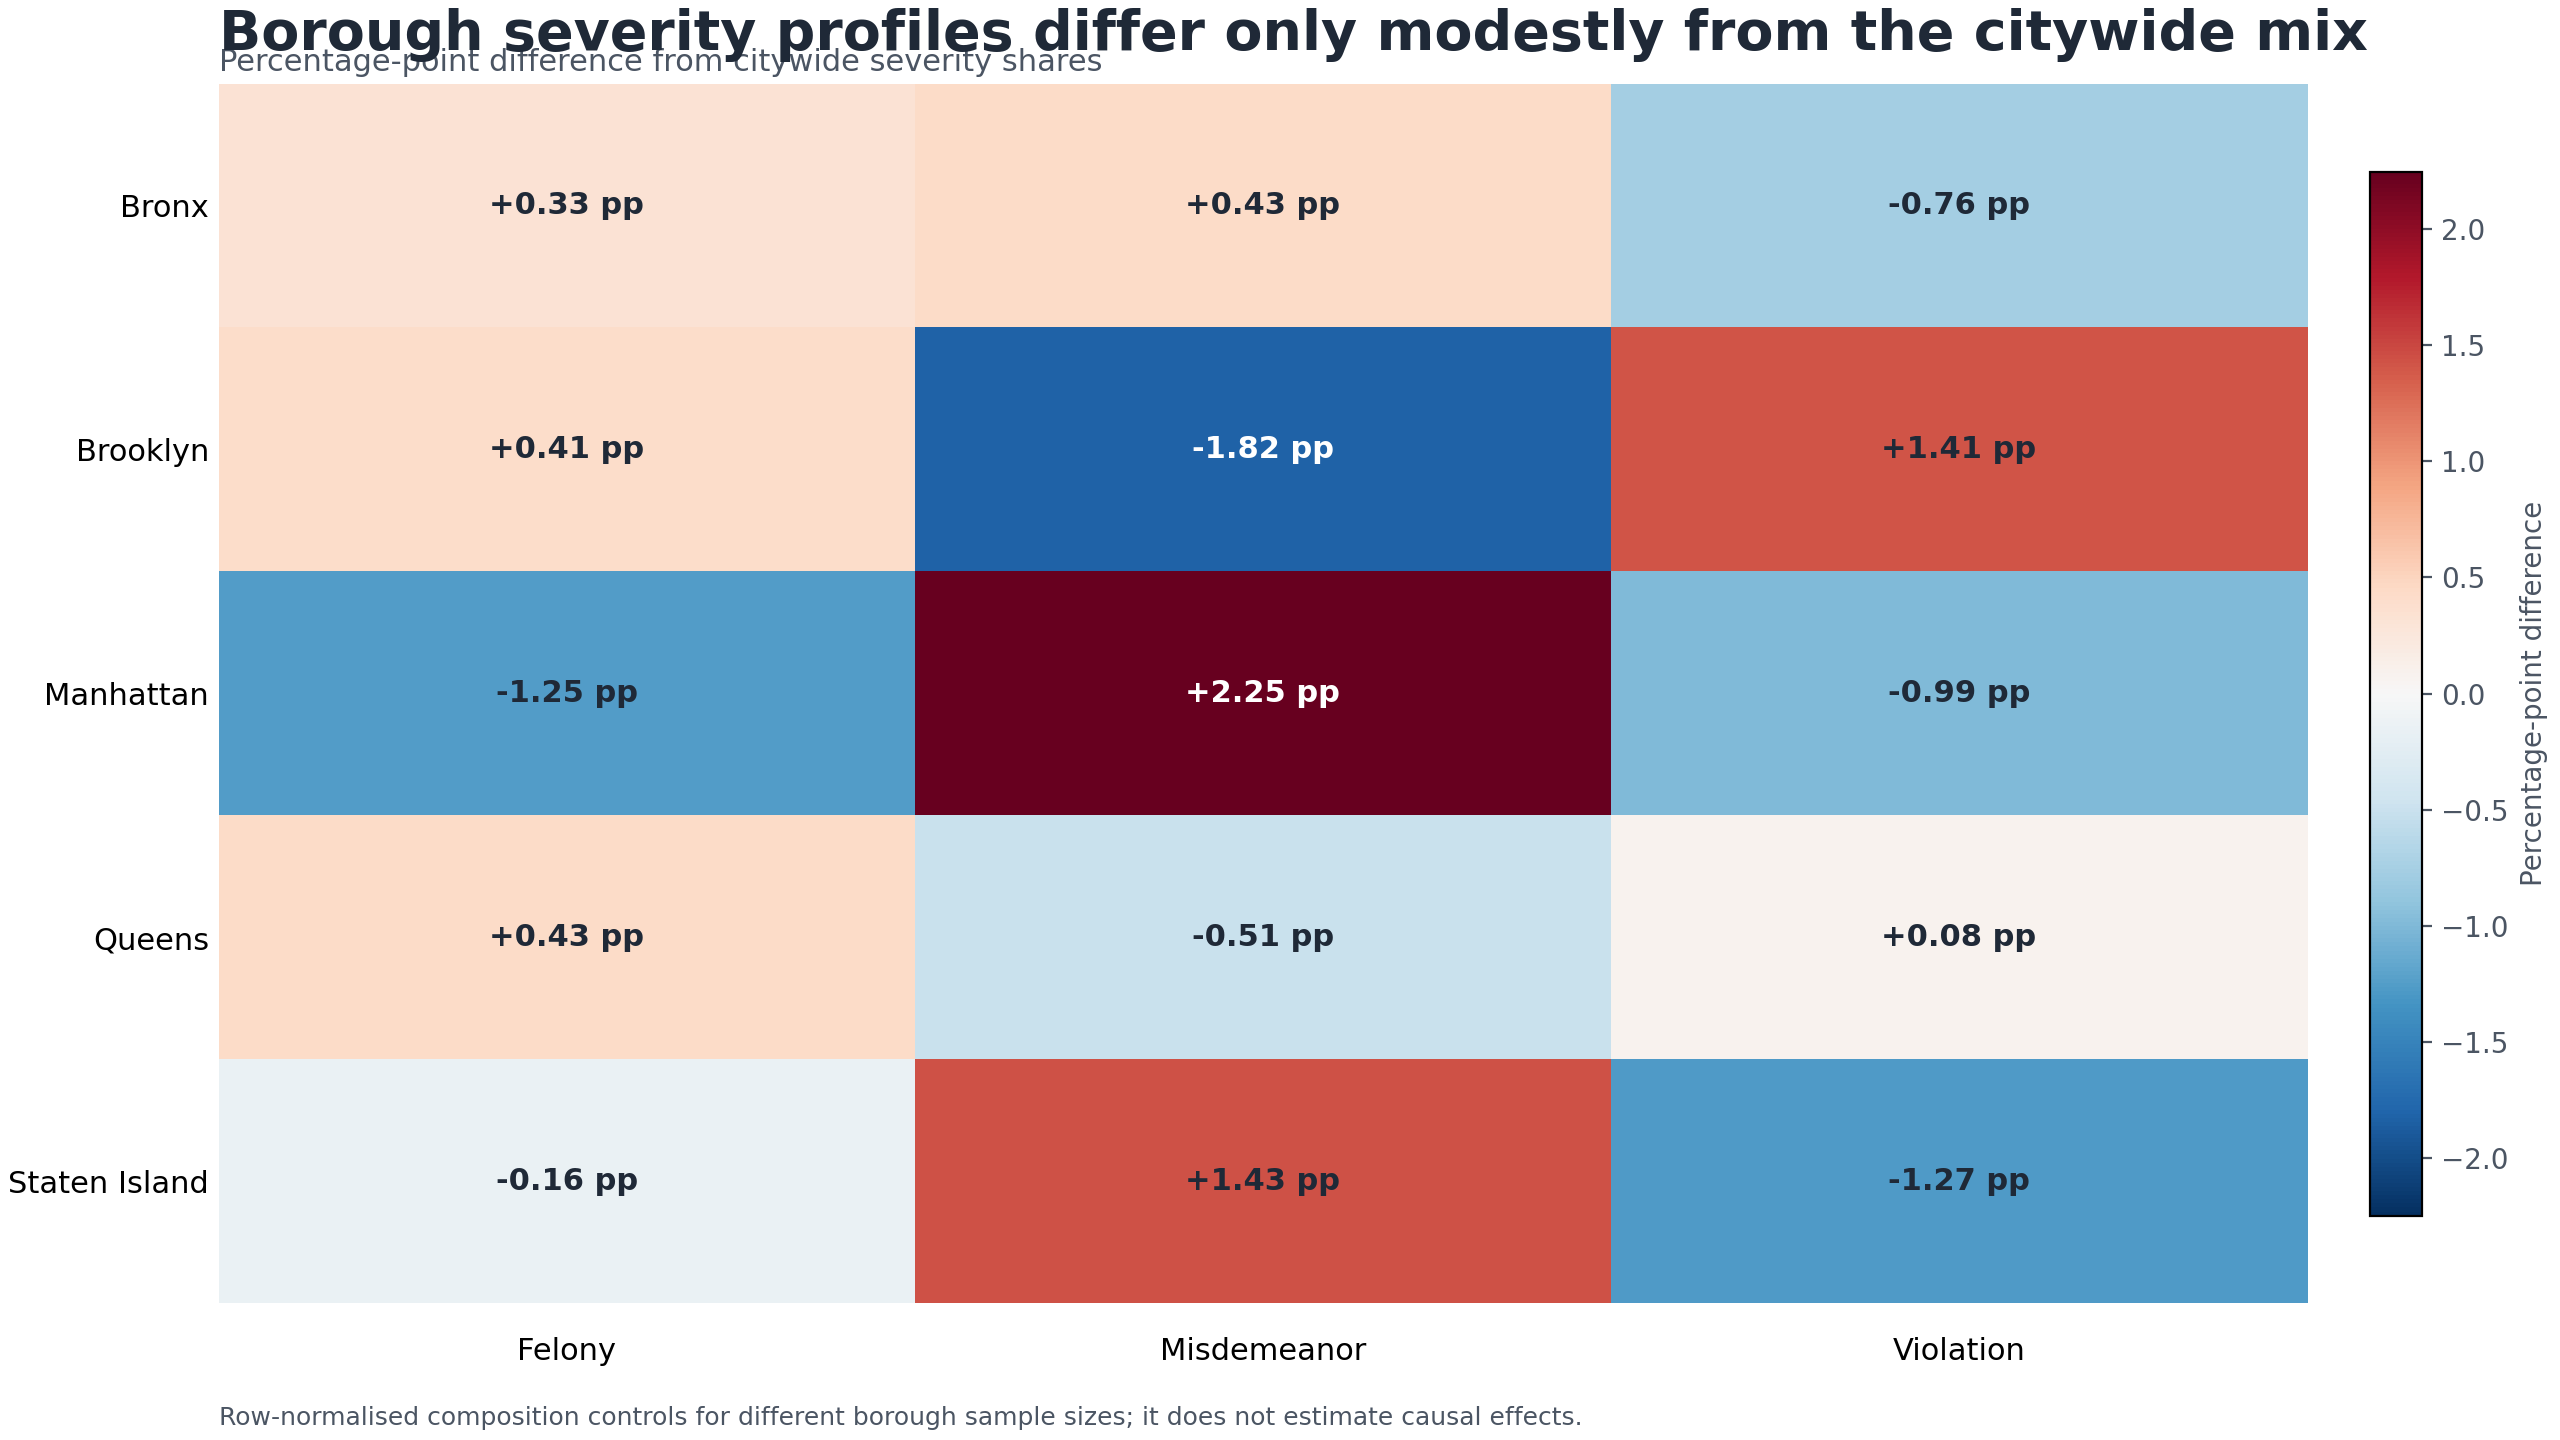

In [9]:
display(Image(filename=str(FIGURE_DIR / '04_borough_severity_deviation.png'), width=1000))

Borough composition differences are modest. Row-normalised shares separate severity composition from the unequal number of records in each borough.

## 5. Interpretation boundary

- Arrest records reflect policing, reporting, enforcement, and administrative processes.
- Raw geographic counts are not population-adjusted rates.
- The six-month snapshot is not evidence of a long-term trend.
- Associations do not establish causal relationships.
- F/M/V composition excludes 1,394 missing/non-core records; that denominator is stated in all relevant outputs.